# DISCO: Distributed Synthetic Control Explanations - Demo

This notebook demonstrates the complete DISCO pipeline for privacy-preserving, peer-based treatment-effect explanations.

## 1. Setup and Imports

In [1]:
# Add parent directory to path
import sys
import os
sys.path.append(os.path.abspath('../..'))

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# DISCO imports
from disco.data.loaders import load_adult, load_synthetic_tabular, stack_prewindow
from disco.data.splits import split_across_devices
from disco.devices.sklearn_tabular import SklearnDevice
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift
from disco.interventions.grids import Grids, create_grids
from disco.anchors.knn import AnchorSelector
from disco.matching.weights import WeightSolver, MatchInputs
from disco.matching.metrics import (
    compute_weight_sparsity, compute_effective_peers,
    compute_weight_entropy, identify_active_peers
)
from disco.counterfactual.smode import SModeCounterfactual
from disco.counterfactual.pmode import PModeCounterfactual
from disco.explain.te_curve import Explainer
from disco.explain.plotting import (
    plot_te_curve, plot_weight_distribution,
    plot_multiple_interventions, plot_diagnostics
)
from disco.cli.main import compute_probe_trajectories, run_disco_pipeline

print("DISCO modules loaded successfully!")

DISCO modules loaded successfully!


## 2. Load and Prepare Data

In [2]:
# Load Adult Income dataset
print("Loading Adult Income dataset...")
try:
    X_train, y_train, X_test, y_test = load_adult()
    print(f"Training set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    print(f"Classes: {np.unique(y_train)}")
except Exception as e:
    print(f"Could not load Adult dataset: {e}")
    print("Falling back to synthetic data...")
    X_train, y_train, X_test, y_test = load_synthetic_tabular(
        n_samples=2000, n_features=10, n_classes=2, seed=42
    )
    print(f"Synthetic training set: {X_train.shape}")
    print(f"Synthetic test set: {X_test.shape}")

Loading Adult Income dataset...
Training set: (39073, 14)
Test set: (9769, 14)
Classes: [0 1]


## 3. Create Heterogeneous Devices with Non-IID Data

In [3]:
# Split data across devices with label skew
N_DEVICES = 5
splits = split_across_devices(
    X_train, y_train, N=N_DEVICES, 
    strategy="label_skew", seed=42
)

# Train heterogeneous models
devices = []
model_types = [
    LogisticRegression(max_iter=200, random_state=42),
    RandomForestClassifier(n_estimators=50, random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    LogisticRegression(C=0.1, max_iter=200, random_state=42),
    RandomForestClassifier(n_estimators=20, max_depth=3, random_state=42)
]

for i, ((X_i, y_i), model) in enumerate(zip(splits, model_types)):
    print(f"Device {i+1}: Training {model.__class__.__name__} on {len(X_i)} samples")
    print(f"  Label distribution: {np.bincount(y_i)}")
    
    model.fit(X_i, y_i)
    device = SklearnDevice(
        id=f"device_{i+1}",
        model=model,
        task="classification",
        scalarization="prob"
    )
    devices.append(device)
    
    # Test accuracy
    acc = model.score(X_test[:500], y_test[:500])
    print(f"  Test accuracy: {acc:.3f}")

Device 1: Training LogisticRegression on 4557 samples
  Label distribution: [4232  325]
  Test accuracy: 0.832
Device 2: Training RandomForestClassifier on 21409 samples
  Label distribution: [19803  1606]
  Test accuracy: 0.858
Device 3: Training DecisionTreeClassifier on 790 samples
  Label distribution: [733  57]
  Test accuracy: 0.858
Device 4: Training LogisticRegression on 109 samples
  Label distribution: [97 12]
  Test accuracy: 0.792
Device 5: Training RandomForestClassifier on 20269 samples
  Label distribution: [15578  4691]
  Test accuracy: 0.858


## 4. Define Interventions and Grids

In [4]:
# Define interventions on different features
interventions = [
    FeatureAdd(feat_idx=0, delta_max=3.0, name="add_feature_0"),
    FeatureScale(feat_idx=1, scale_max=0.5, name="scale_feature_1"),
    ClampedShift(feat_idx=2, shift_max=2.0, lower=-2.0, upper=2.0, name="clamped_feature_2")
]

# Create grids with proper separation
grids = Grids(
    theta0=np.array([0.0, 0.3, 0.6]),  # Pre-window
    theta=np.linspace(1.0, 3.0, 8)     # Post-grid
)

print(f"Pre-window: {grids.theta0}")
print(f"Post-grid: {grids.theta}")

Pre-window: [0.  0.3 0.6]
Post-grid: [1.         1.28571429 1.57142857 1.85714286 2.14285714 2.42857143
 2.71428571 3.        ]


## 5. Compute Public Probe Trajectories

In [5]:
# Select public probe set
PROBE_SIZE = 500
X_probe = X_test[:PROBE_SIZE]
print(f"Probe set size: {X_probe.shape}")

# Compute pre-window trajectories for all devices and interventions
trajectories = compute_probe_trajectories(
    devices=devices,
    X_probe=X_probe,
    interventions=interventions,
    theta0=grids.theta0,
    target_class=1,  # Positive class
    dp_noise=0.0     # No DP noise for now
)

print(f"Computed {len(trajectories)} trajectory matrices")
print(f"Each trajectory shape: {list(trajectories.values())[0].shape}")

Probe set size: (500, 14)
Computed 15 trajectory matrices
Each trajectory shape: (500, 3)


## 6. Run DISCO Pipeline for a Query

In [6]:
# Select target device and private query
target_device = devices[0]
x_star_idx = 777
x_star = X_test[x_star_idx:x_star_idx+1]
true_label = y_test[x_star_idx]

print(f"Target device: {target_device.id}")
print(f"Query point index: {x_star_idx}")
print(f"True label: {true_label}")

# Target's initial prediction
initial_pred = target_device.model.predict(x_star)[0]
initial_prob = target_device.model.predict_proba(x_star)[0, 1]
print(f"Target's initial prediction: {initial_pred} (prob={initial_prob:.3f})")

Target device: device_1
Query point index: 777
True label: 1
Target's initial prediction: 0 (prob=0.123)


In [7]:
# Initialize DISCO components
anchor_selector = AnchorSelector(emb=lambda X: X, K=50, tau=0.5)
weight_solver = WeightSolver(method="projected_grad", max_iter=1000)
explainer = Explainer(compute_flip=True)

# Run pipeline for first intervention
intervention = interventions[0]
print(f"\nRunning DISCO for intervention: {intervention.name}")

results = run_disco_pipeline(
    target_device=target_device,
    devices=devices,
    x_star=x_star,
    X_probe=X_probe,
    intervention=intervention,
    grids=grids,
    anchor_selector=anchor_selector,
    weight_solver=weight_solver,
    counterfactual_builder=PModeCounterfactual(),  # Using P-mode
    explainer=explainer,
    trajectories=trajectories,
    target_class=1,
    mode="p"
)

# Display results
print(f"\nResults:")
print(f"  Pre-window fit error: {results['eps_pre']:.4f}")
print(f"  Anchor radius: {results['anchor_radius']:.4f}")
print(f"  Proxy bias: {results['proxy_bias']:.4f}")
print(f"  Effective peers: {results['n_effective_peers']}")
print(f"  AUC-TE: {results['te_output'].auc_abs:.4f}")
print(f"  Peak treatment effect: {results['te_output'].peak_tau:.4f}")
if results['te_output'].flip_theta is not None:
    print(f"  Flip intensity: {results['te_output'].flip_theta:.4f}")


Running DISCO for intervention: add_feature_0

Results:
  Pre-window fit error: 0.0050
  Anchor radius: 1.4274
  Proxy bias: 0.0275
  Effective peers: 3
  AUC-TE: 0.1187
  Peak treatment effect: 0.1202


## 7. Visualizations

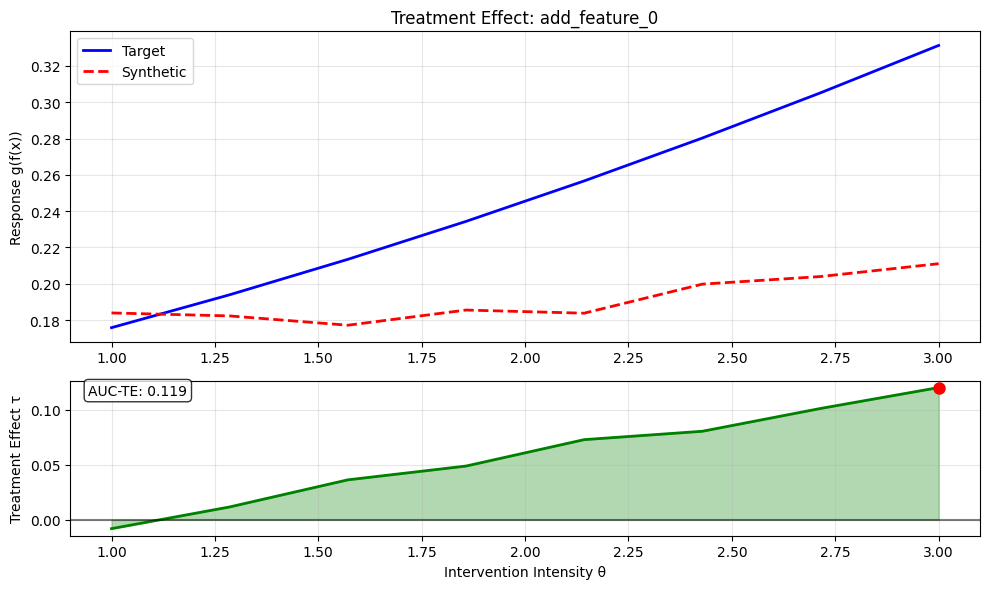

In [8]:
# Plot treatment effect curve
fig = plot_te_curve(
    results['te_output'],
    title=f"Treatment Effect: {intervention.name}",
    show_auc=True,
    show_flip=True
)
plt.show()

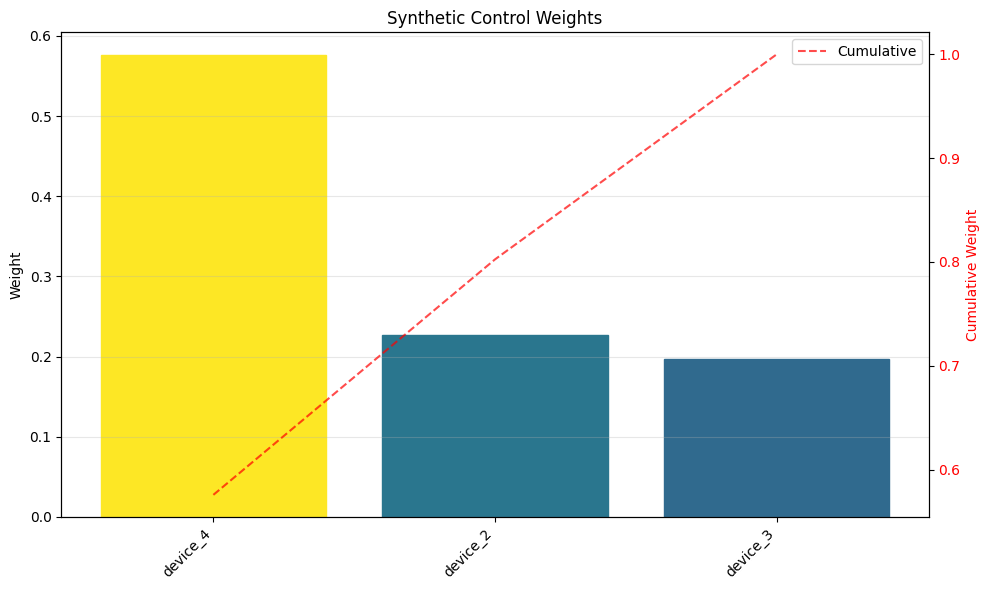


Active peers (weight > 0.01):
  device_4: 0.576
  device_2: 0.227
  device_3: 0.198


In [9]:
# Plot weight distribution
peer_ids = [d.id for d in devices if d.id != target_device.id]
fig = plot_weight_distribution(
    results['weights'],
    peer_ids=peer_ids,
    threshold=0.01
)
plt.show()

# Identify active peers
active_peers = identify_active_peers(
    results['weights'], peer_ids, threshold=0.01
)
print("\nActive peers (weight > 0.01):")
for peer_id, weight in active_peers:
    print(f"  {peer_id}: {weight:.3f}")

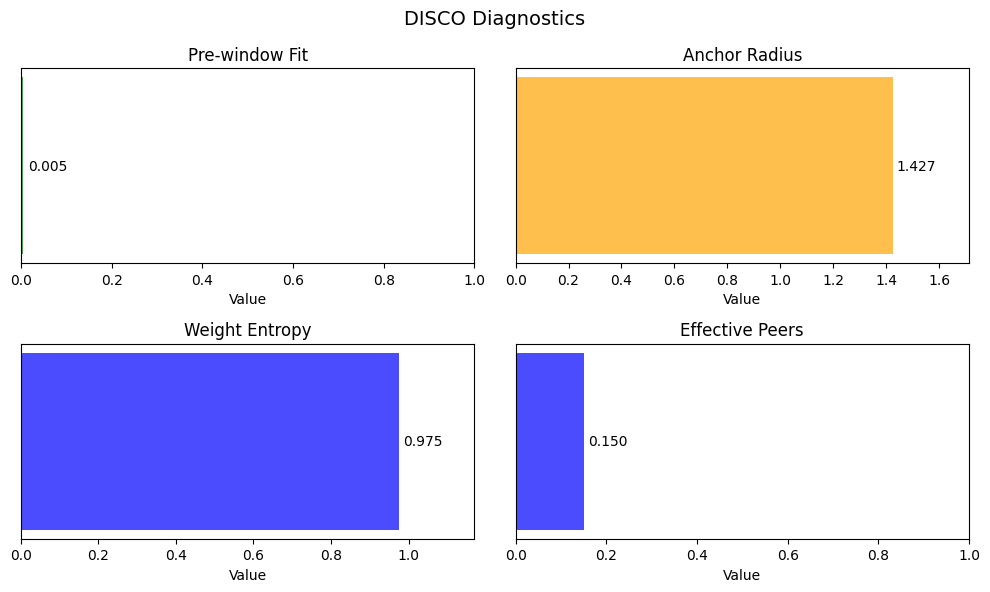

In [10]:
# Plot diagnostics dashboard
fig = plot_diagnostics(
    eps_pre=results['eps_pre'],
    anchor_radius=results['anchor_radius'],
    weight_entropy=results['weight_entropy'],
    n_effective_peers=results['n_effective_peers']
)
plt.show()

## 8. Compare Multiple Interventions

In [11]:
# Run DISCO for all interventions
all_results = {}

for intervention in interventions:
    print(f"Processing {intervention.name}...")
    
    results = run_disco_pipeline(
        target_device=target_device,
        devices=devices,
        x_star=x_star,
        X_probe=X_probe,
        intervention=intervention,
        grids=grids,
        anchor_selector=anchor_selector,
        weight_solver=weight_solver,
        counterfactual_builder=PModeCounterfactual(),
        explainer=explainer,
        trajectories=trajectories,
        target_class=1,
        mode="p"
    )
    
    all_results[intervention.name] = results['te_output']
    print(f"  AUC-TE: {results['te_output'].auc_abs:.4f}")

Processing add_feature_0...
  AUC-TE: 0.1187
Processing scale_feature_1...
  AUC-TE: 0.1490
Processing clamped_feature_2...
  AUC-TE: 0.0555


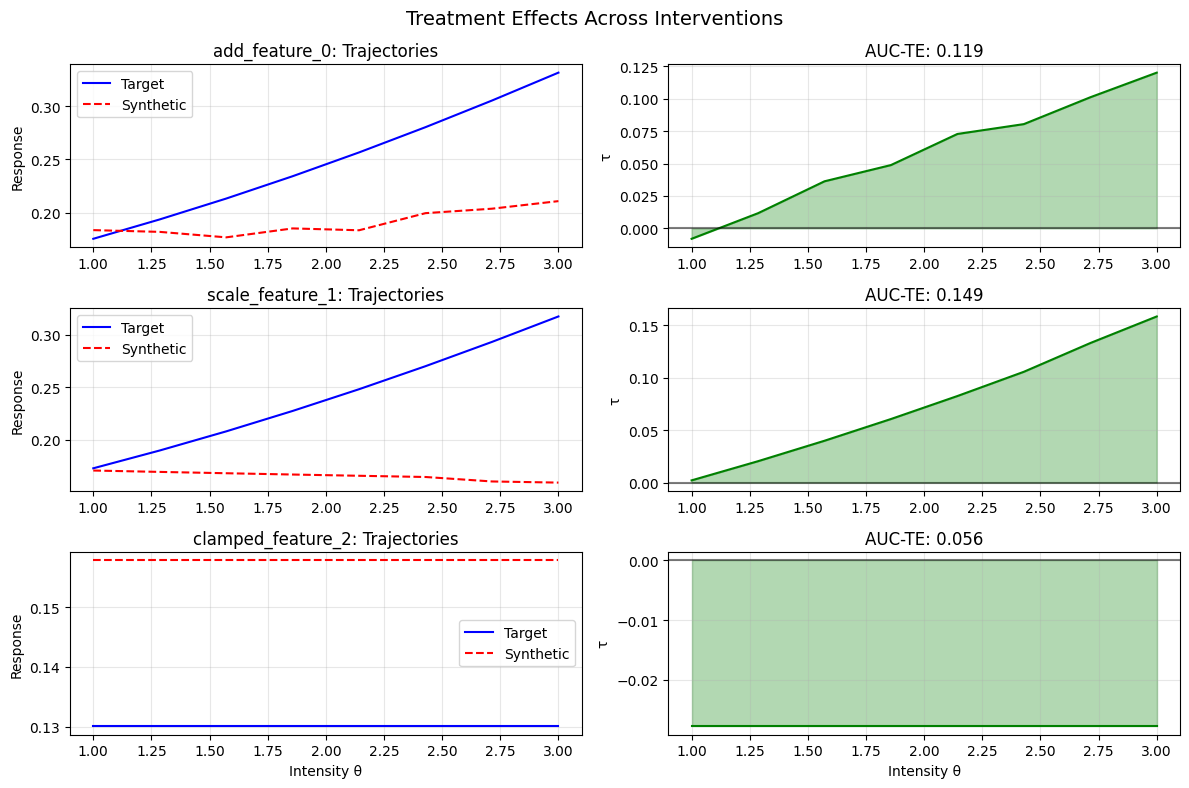

In [12]:
# Plot comparison
fig = plot_multiple_interventions(all_results)
plt.show()

## 9. Compare S-mode vs P-mode

In [14]:
# Run both modes for comparison
intervention = interventions[0]

# P-mode
results_p = run_disco_pipeline(
    target_device=target_device,
    devices=devices,
    x_star=x_star,
    X_probe=X_probe,
    intervention=intervention,
    grids=grids,
    anchor_selector=anchor_selector,
    weight_solver=weight_solver,
    counterfactual_builder=PModeCounterfactual(),
    explainer=explainer,
    trajectories=trajectories,
    target_class=1,
    mode="p"
)

# S-mode
results_s = run_disco_pipeline(
    target_device=target_device,
    devices=devices,
    x_star=x_star,
    X_probe=X_probe,
    intervention=intervention,
    grids=grids,
    anchor_selector=anchor_selector,
    weight_solver=weight_solver,
    counterfactual_builder=SModeCounterfactual(),
    explainer=explainer,
    trajectories=trajectories,
    target_class=1,
    mode="s"
)

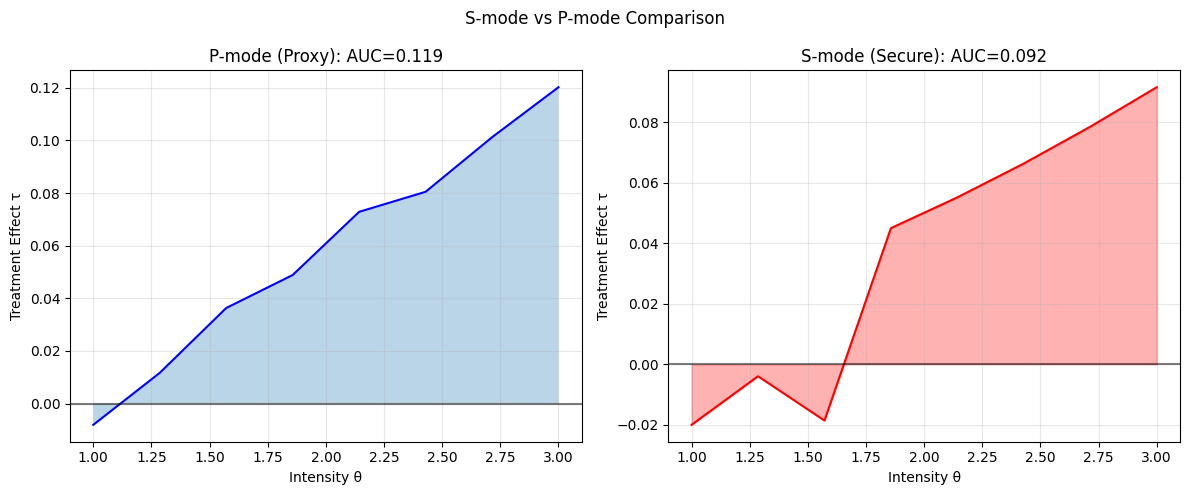


Difference between S-mode and P-mode:
  Mean absolute difference: 0.021209
  Max absolute difference: 0.054892
  Proxy bias (P-mode): 0.027461


In [15]:
# Compare results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# P-mode
ax = axes[0]
ax.plot(results_p['te_output'].theta, results_p['te_output'].tau, 'b-', label='P-mode')
ax.fill_between(results_p['te_output'].theta, 0, results_p['te_output'].tau, alpha=0.3)
ax.set_xlabel('Intensity θ')
ax.set_ylabel('Treatment Effect τ')
ax.set_title(f"P-mode (Proxy): AUC={results_p['te_output'].auc_abs:.3f}")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# S-mode
ax = axes[1]
ax.plot(results_s['te_output'].theta, results_s['te_output'].tau, 'r-', label='S-mode')
ax.fill_between(results_s['te_output'].theta, 0, results_s['te_output'].tau, alpha=0.3, color='red')
ax.set_xlabel('Intensity θ')
ax.set_ylabel('Treatment Effect τ')
ax.set_title(f"S-mode (Secure): AUC={results_s['te_output'].auc_abs:.3f}")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)

plt.suptitle('S-mode vs P-mode Comparison')
plt.tight_layout()
plt.show()

# Compute difference
tau_diff = results_s['te_output'].tau - results_p['te_output'].tau
print(f"\nDifference between S-mode and P-mode:")
print(f"  Mean absolute difference: {np.mean(np.abs(tau_diff)):.6f}")
print(f"  Max absolute difference: {np.max(np.abs(tau_diff)):.6f}")
print(f"  Proxy bias (P-mode): {results_p['proxy_bias']:.6f}")

## 10. Stability Analysis

Running bootstrap stability analysis...

Stability Metrics:
  Mean L1 distance between weights: 0.1824
  Std L1 distance: 0.0914
  Pre-window fit mean: 0.0054
  Pre-window fit std: 0.0003


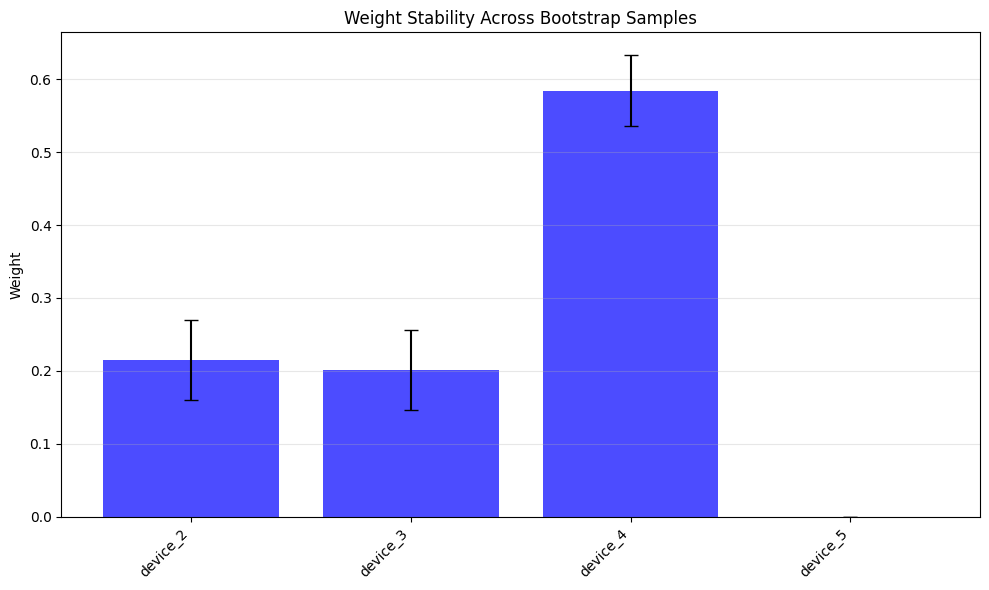

In [16]:
from disco.matching.metrics import bootstrap_stability

# Prepare matching inputs
intervention = interventions[0]
anchor_sel = anchor_selector.select(X_probe, x_star)
y_t, X_peers = stack_prewindow(
    trajectories, target_device, devices,
    anchor_sel, intervention, grids.theta0
)
match_inputs = MatchInputs(y_t=y_t, X_peers=X_peers, lam=0.01)

# Bootstrap stability analysis
print("Running bootstrap stability analysis...")
stability = bootstrap_stability(
    solver=weight_solver,
    inputs=match_inputs,
    n_bootstrap=50,
    sample_frac=0.8,
    seed=42
)

print(f"\nStability Metrics:")
print(f"  Mean L1 distance between weights: {stability['mean_l1_distance']:.4f}")
print(f"  Std L1 distance: {stability['std_l1_distance']:.4f}")
print(f"  Pre-window fit mean: {stability['eps_pre_mean']:.4f}")
print(f"  Pre-window fit std: {stability['eps_pre_std']:.4f}")

# Plot weight stability
fig, ax = plt.subplots(figsize=(10, 6))
peer_ids = [d.id for d in devices if d.id != target_device.id]
x = np.arange(len(peer_ids))
ax.bar(x, stability['mean_weights'], yerr=stability['std_weights'], 
       capsize=5, alpha=0.7, color='blue')
ax.set_xticks(x)
ax.set_xticklabels(peer_ids, rotation=45, ha='right')
ax.set_ylabel('Weight')
ax.set_title('Weight Stability Across Bootstrap Samples')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Summary and Key Findings

In [17]:
print("=" * 50)
print("DISCO EXPERIMENT SUMMARY")
print("=" * 50)
print(f"\nSetup:")
print(f"  - {N_DEVICES} heterogeneous devices")
print(f"  - Non-IID data (label skew)")
print(f"  - {len(interventions)} interventions tested")
print(f"  - Probe set size: {PROBE_SIZE}")
print(f"  - Anchor neighbors: K={anchor_selector.K}")

print(f"\nKey Metrics:")
for name, te_out in all_results.items():
    print(f"\n  {name}:")
    print(f"    - AUC-TE: {te_out.auc_abs:.4f}")
    print(f"    - Peak |τ|: {te_out.peak_tau:.4f}")
    if te_out.flip_theta is not None:
        print(f"    - Flip at θ={te_out.flip_theta:.3f}")

print(f"\nDiagnostics:")
print(f"  - Pre-window fit: {results['eps_pre']:.4f}")
print(f"  - Anchor radius: {results['anchor_radius']:.4f}")
print(f"  - Effective peers: {results['n_effective_peers']}/{N_DEVICES-1}")
print(f"  - Weight entropy: {results['weight_entropy']:.3f}")

print(f"\nMode Comparison:")
print(f"  - P-mode AUC-TE: {results_p['te_output'].auc_abs:.4f}")
print(f"  - S-mode AUC-TE: {results_s['te_output'].auc_abs:.4f}")
print(f"  - Proxy bias: {results_p['proxy_bias']:.6f}")

print("\n" + "=" * 50)
print("Experiment completed successfully!")
print("=" * 50)

DISCO EXPERIMENT SUMMARY

Setup:
  - 5 heterogeneous devices
  - Non-IID data (label skew)
  - 3 interventions tested
  - Probe set size: 500
  - Anchor neighbors: K=50

Key Metrics:

  add_feature_0:
    - AUC-TE: 0.1187
    - Peak |τ|: 0.1202

  scale_feature_1:
    - AUC-TE: 0.1490
    - Peak |τ|: 0.1582

  clamped_feature_2:
    - AUC-TE: 0.0555
    - Peak |τ|: -0.0278

Diagnostics:
  - Pre-window fit: 0.0045
  - Anchor radius: 1.4274
  - Effective peers: 3/4
  - Weight entropy: 0.989

Mode Comparison:
  - P-mode AUC-TE: 0.1187
  - S-mode AUC-TE: 0.0923
  - Proxy bias: 0.027461

Experiment completed successfully!
